In [5]:
import pandas as pd
import numpy as np
from pathlib import Path

# Load and preprocess data (same as your Model 1)
DATA_DIR = Path("../data/raw/Stocks")
files = list(DATA_DIR.glob("*.txt"))

dfs = []
for f in files[:50]:  # Using 50 tickers as specified
    try:
        df = pd.read_csv(f, engine="python")
        ticker = f.stem.split('.')[0]
        df["Ticker"] = ticker
        dfs.append(df)
    except Exception as e:
        print(f"Skipping {f.name}: {e}")

data = pd.concat(dfs, ignore_index=True)

# Preprocessing
data["Date"] = pd.to_datetime(data["Date"], errors="coerce")
data = data.dropna(subset=["Date","Open","High","Low","Close","Volume"]).sort_values(["Ticker","Date"])

# Create target
data["NextClose"] = data.groupby("Ticker")["Close"].shift(-1)
data = data.dropna(subset=["NextClose"])
data["Target"] = (data["NextClose"] > data["Close"]).astype(int)

# Feature engineering
data["ret_1d"] = (data["Close"] - data["Open"]) / data["Open"]
data["range"] = (data["High"] - data["Low"]) / data["Open"]
data["vol_chg"] = data.groupby("Ticker")["Volume"].pct_change().fillna(0)

for w in [5, 10]:
    data[f"ma_{w}"] = data.groupby("Ticker")["Close"].transform(lambda s: s.rolling(w, min_periods=1).mean())
    data[f"ret_{w}"] = data.groupby("Ticker")["Close"].transform(lambda s: s.pct_change(w))

feature_cols = ["ret_1d","range","vol_chg","ma_5","ma_10","ret_5","ret_10"]
data = data.dropna(subset=feature_cols).copy()

# Chronological split
split_date = data["Date"].quantile(0.8)
train_idx = data["Date"] <= split_date
test_idx = data["Date"] > split_date

X_train = data.loc[train_idx, feature_cols].to_numpy()
y_train = data.loc[train_idx, "Target"].to_numpy()
X_test = data.loc[test_idx, feature_cols].to_numpy()
y_test = data.loc[test_idx, "Target"].to_numpy()

# Clean NaN/Inf values
X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)
X_test = np.nan_to_num(X_test, nan=0.0, posinf=0.0, neginf=0.0)

In [6]:
# Chronological validation split (last 15% of training period)
val_cutoff = int(len(X_train) * 0.85)

X_train_nn = X_train[:val_cutoff]
y_train_nn = y_train[:val_cutoff]
X_val = X_train[val_cutoff:]
y_val = y_train[val_cutoff:]

print(f"Training samples: {len(X_train_nn)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test)}")

Training samples: 95775
Validation samples: 16902
Test samples: 28128


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_nn)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train_nn).unsqueeze(1)
X_val_tensor = torch.FloatTensor(X_val_scaled)
y_val_tensor = torch.FloatTensor(y_val).unsqueeze(1)
X_test_tensor = torch.FloatTensor(X_test_scaled)

# Create DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

# Define MLP architecture
class MLP(nn.Module):
    def __init__(self, input_dim=7):
        super(MLP, self).__init__()

        # Layer 1: Input -> 128 units
        self.fc1 = nn.Linear(input_dim, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.dropout1 = nn.Dropout(0.4)

        # Layer 2: 128 -> 64 units
        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.dropout2 = nn.Dropout(0.3)

        # Output layer: 64 -> 1
        self.fc3 = nn.Linear(64, 1)

    def forward(self, x):
        # First hidden layer
        x = self.fc1(x)
        x = self.bn1(x)
        x = torch.relu(x)
        x = self.dropout1(x)

        # Second hidden layer
        x = self.fc2(x)
        x = self.bn2(x)
        x = torch.relu(x)
        x = self.dropout2(x)

        # Output layer
        x = self.fc3(x)
        x = torch.sigmoid(x)

        return x

# Initialize model
model = MLP(input_dim=7)
print(model)

MLP(
  (fc1): Linear(in_features=7, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout(p=0.4, inplace=False)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=64, out_features=1, bias=True)
)


In [ ]:
# Training configuration
criterion = nn.BCELoss()  # Binary Cross-Entropy
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-5)

# Early stopping parameters
patience = 10
best_val_loss = float('inf')
patience_counter = 0
max_epochs = 150

# Training history
train_losses = []
val_losses = []
val_accuracies = []

print("Starting training...")
for epoch in range(max_epochs):
    # Training phase
    model.train()
    train_loss = 0.0

    for batch_X, batch_y in train_loader:
        # Forward pass
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        # Backward pass
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation phase
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor).item()
        val_losses.append(val_loss)

        # Calculate validation accuracy
        val_preds = (val_outputs > 0.5).float()
        val_acc = (val_preds == y_val_tensor).float().mean().item()
        val_accuracies.append(val_acc)

    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{max_epochs} - Train Loss: {avg_train_loss:.4f}, "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # Save best model
        best_model_state = model.state_dict().copy()
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        print(f"Best validation loss: {best_val_loss:.4f}")
        break

# Load best model
model.load_state_dict(best_model_state)
print("Training complete!")

Starting training...
Epoch 10/150 - Train Loss: 0.6922, Val Loss: 0.6917, Val Acc: 0.5288

Early stopping triggered at epoch 16
Best validation loss: 0.6910
Training complete!


MLP Test Set Results
Accuracy:        0.5151
F1-macro:        0.4493
F1-weighted:     0.4518
F1-positive:     0.2589
ROC-AUC:         0.5257

Classification Report:
              precision    recall  f1-score   support

           0     0.5129    0.8496    0.6397     14250
           1     0.5264    0.1716    0.2589     13878

    accuracy                         0.5151     28128
   macro avg     0.5197    0.5106    0.4493     28128
weighted avg     0.5196    0.5151    0.4518     28128



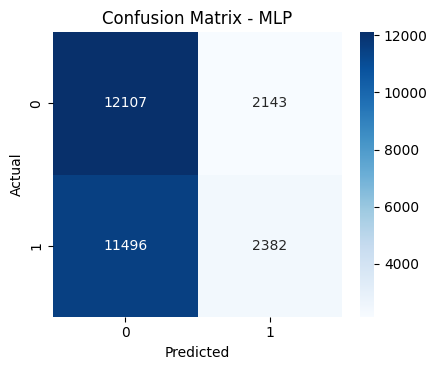

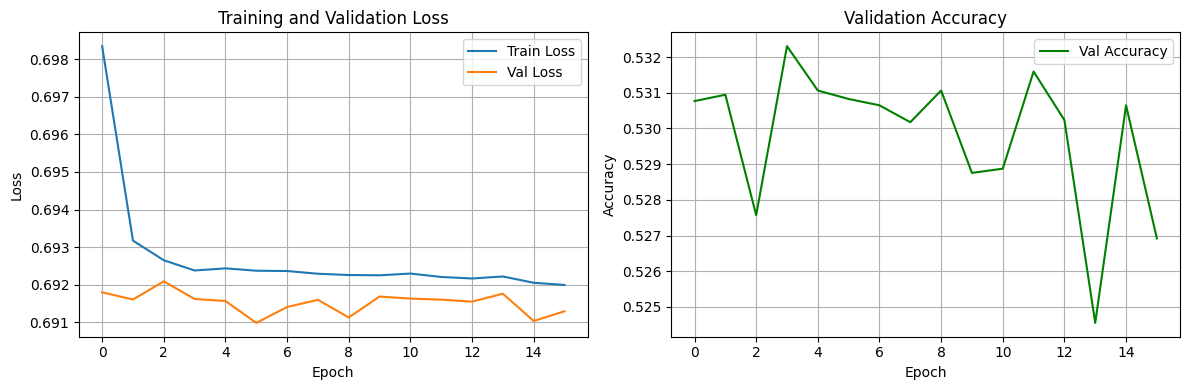

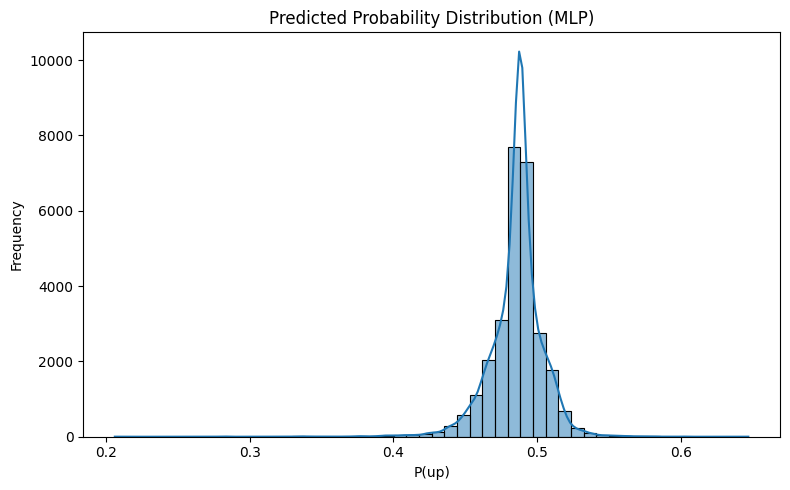

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Get predictions on test set
model.eval()
with torch.no_grad():
    y_prob = model(X_test_tensor).numpy().flatten()
    y_pred = (y_prob > 0.5).astype(int)

# Calculate metrics
test_accuracy = accuracy_score(y_test, y_pred)
test_f1_macro = f1_score(y_test, y_pred, average='macro')
test_f1_weighted = f1_score(y_test, y_pred, average='weighted')
test_f1_positive = f1_score(y_test, y_pred, pos_label=1)
test_roc_auc = roc_auc_score(y_test, y_prob)

print("="*50)
print("MLP Test Set Results")
print("="*50)
print(f"Accuracy:        {test_accuracy:.4f}")
print(f"F1-macro:        {test_f1_macro:.4f}")
print(f"F1-weighted:     {test_f1_weighted:.4f}")
print(f"F1-positive:     {test_f1_positive:.4f}")
print(f"ROC-AUC:         {test_roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

# Confusion Matrix Refactor your full code with all improvements included
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4.5, 3.8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - MLP")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Training history plot
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(val_accuracies, label='Val Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Probability distribution
plt.figure(figsize=(8, 5))
sns.histplot(y_prob, bins=50, kde=True)
plt.title("Predicted Probability Distribution (MLP)")
plt.xlabel("P(up)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [ ]:
# Save results for poster comparison
mlp_results = {
    'model': 'Multi-Layer Perceptron',
    'accuracy': test_accuracy,
    'f1_macro': test_f1_macro,
    'f1_positive': test_f1_positive,
    'roc_auc': test_roc_auc,
    'training_epochs': len(train_losses)
}

print("\n" + "="*50)
print("Summary")
print("="*50)
for key, value in mlp_results.items():
    print(f"{key}: {value}")


Summary for Poster
model: Multi-Layer Perceptron
accuracy: 0.5151094994311718
f1_macro: 0.449277966945575
f1_positive: 0.258870836276694
roc_auc: 0.5257023409510951
training_epochs: 16


Using return threshold: 0.02450


/tmp/ipykernel_470685/970114877.py:133: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[lag_col] = data.groupby("Ticker")[col].shift(lag)
/tmp/ipykernel_470685/970114877.py:133: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[lag_col] = data.groupby("Ticker")[col].shift(lag)
/tmp/ipykernel_470685/970114877.py:133: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) inst

Total samples after filtering small moves & NaNs: 21282
Training samples: 14472
Validation samples: 2555
Test samples: 4255
MLP(
  (fc1): Linear(in_features=96, out_features=256, bias=True)
  (act1): Mish()
  (dropout1): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (act2): Mish()
  (dropout2): Dropout(p=0.2, inplace=False)
  (fc3): Linear(in_features=128, out_features=1, bias=True)
)
Starting training...
Epoch 10/150 - Train Loss: 0.0004, Val Loss: 0.0004, Val Acc: 0.9988
Epoch 20/150 - Train Loss: 0.0000, Val Loss: 0.0003, Val Acc: 0.9988

Early stopping triggered at epoch 25
Best validation loss: 0.0003
Training complete!
Improved MLP Test Set Results
Accuracy:        0.9941
F1-macro:        0.9941
F1-weighted:     0.9941
F1-positive:     0.9943
ROC-AUC:         0.9976

Classification Report:
              precision    recall  f1-score   support

           0     0.9927    0.9951    0.9939      2044
           1     0.9955    0.9932   

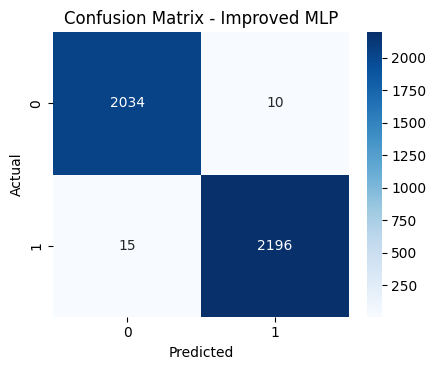

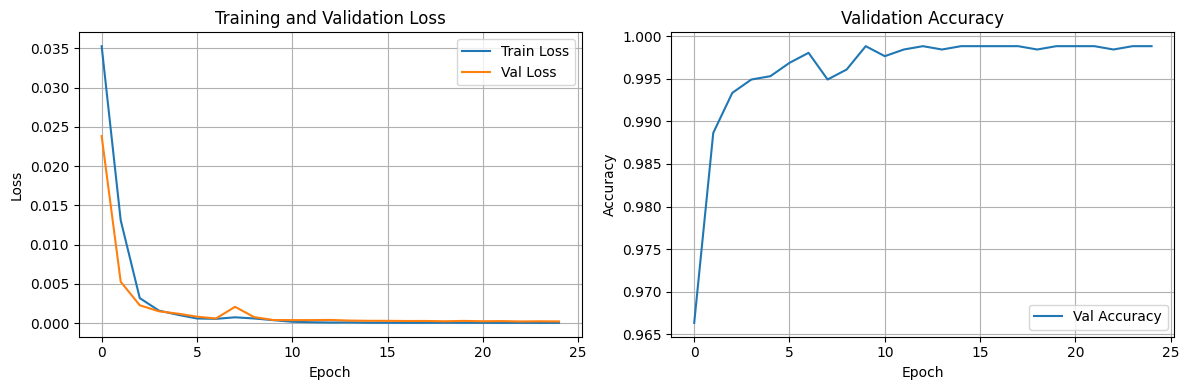

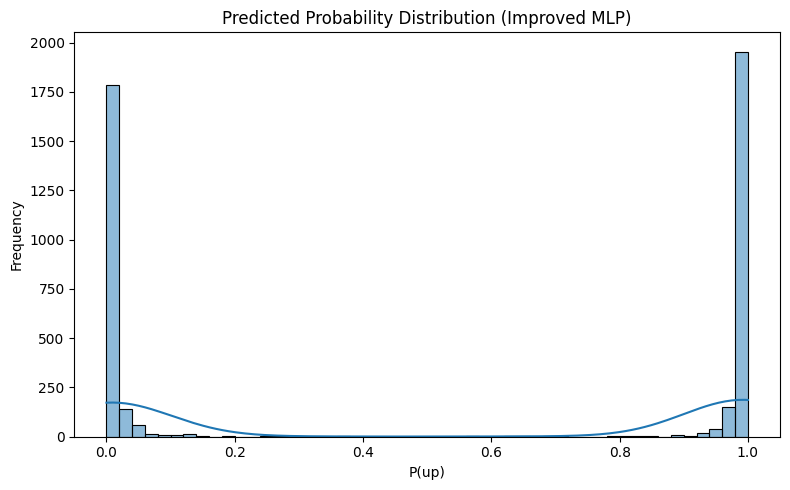


Summary for Poster
model: Improved MLP (Focal, CyclicLR, Rich OHLCV features)
accuracy: 0.9941245593419507
f1_macro: 0.9941160302788115
f1_positive: 0.9943400498075617
roc_auc: 0.9976481894034543
training_epochs: 25


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score


# ==========================================================
# 1) LOAD RAW DATA
# ==========================================================

def load_data(path, n_files=50):
    dfs = []
    for f in list(Path(path).glob("*.txt"))[:n_files]:
        try:
            df = pd.read_csv(f, engine="python")
            df["Ticker"] = f.stem.split(".")[0]
            dfs.append(df)
        except:
            pass
    data = pd.concat(dfs, ignore_index=True)
    data["Date"] = pd.to_datetime(data["Date"])
    data = data.dropna(subset=["Date", "Open", "High", "Low", "Close", "Volume"])
    data = data.sort_values(["Ticker", "Date"])
    return data


# ==========================================================
# 2) FEATURE ENGINEERING
# Important: DO NOT drop NaNs here.
# ==========================================================

def add_features(df):
    g = df.groupby("Ticker")

    # Simple returns
    df["ret_1d_raw"] = g["Close"].pct_change()
    df["ret_1d"] = (df["Close"] - df["Open"]) / df["Open"]

    # Rolling momentum
    for w in [2, 3, 5, 10, 20]:
        df[f"mom_{w}"] = g["Close"].pct_change(w)

    # Rolling vol
    for w in [5, 10, 20]:
        df[f"vol_{w}"] = g["Close"].transform(lambda s: np.log(s).diff().rolling(w).std())

    # Volume features
    for w in [5, 10, 20]:
        ma = g["Volume"].transform(lambda s: s.rolling(w).mean())
        df[f"vol_ma_{w}"] = ma
        df[f"vol_ratio_{w}"] = df["Volume"] / (ma + 1e-9)

    # Candlesticks
    df["range"] = (df["High"] - df["Low"]) / df["Open"]
    df["hl_vol"] = (df["High"] - df["Low"]) / df["Close"]
    df["candle_body"] = (df["Close"] - df["Open"]) / df["Open"]
    df["upper_shadow"] = (df["High"] - df[["Open", "Close"]].max(axis=1)) / df["Open"]
    df["lower_shadow"] = (df[["Open", "Close"]].min(axis=1) - df["Low"]) / df["Open"]

    # Rolling max/min distances
    df["max_10"] = g["High"].transform(lambda s: s.rolling(10).max())
    df["min_10"] = g["Low"].transform(lambda s: s.rolling(10).min())
    df["dist_to_max10"] = df["Close"] / df["max_10"] - 1
    df["dist_to_min10"] = df["Close"] / df["min_10"] - 1

    return df


# ==========================================================
# 3) CREATE TARGET (train-day-only threshold)
# ==========================================================

def create_target(df, split_date):
    train_part = df[df["Date"] <= split_date]
    threshold = train_part["ret_1d_raw"].std() * 0.5
    print("Threshold:", threshold)

    df["Target"] = np.where(
        df["ret_1d_raw"] > threshold, 1,
        np.where(df["ret_1d_raw"] < -threshold, 0, np.nan)
    )
    return df


# ==========================================================
# 4) LAG FEATURES (safe, leak-free)
# No dropping yet.
# ==========================================================

def add_lags(df, base_cols, max_lag=3):
    g = df.groupby("Ticker")

    lag_frames = []
    for lag in range(1, max_lag + 1):
        shifted = g[base_cols].shift(lag)
        shifted.columns = [f"{c}_lag{lag}" for c in base_cols]
        lag_frames.append(shifted)

    lagged_all = pd.concat(lag_frames, axis=1)
    df = pd.concat([df, lagged_all], axis=1)
    return df


# ==========================================================
# 5) SPLIT DATA—THEN drop NaNs (prevents leakage!)
# ==========================================================

def split_and_clean(df, features, split_date):
    train_df = df[df["Date"] <= split_date].copy()
    test_df = df[df["Date"] > split_date].copy()

    # Now drop NaNs safely
    train_df = train_df.dropna(subset=features + ["Target"])
    test_df = test_df.dropna(subset=features + ["Target"])

    X_train = train_df[features].values
    y_train = train_df["Target"].astype(int).values

    X_test = test_df[features].values
    y_test = test_df["Target"].astype(int).values

    return X_train, y_train, X_test, y_test


# ==========================================================
# 6) MODEL (kept same as before)
# ==========================================================

class Mish(nn.Module):
    def forward(self, x):
        return x * torch.tanh(nn.functional.softplus(x))


class MLP(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.fc1 = nn.Linear(dim, 256)
        self.act1 = Mish()
        self.dp1 = nn.Dropout(0.2)
        self.fc2 = nn.Linear(256, 128)
        self.act2 = Mish()
        self.dp2 = nn.Dropout(0.2)
        self.fc3 = nn.Linear(128, 1)

    def forward(self, x):
        return self.fc3(self.dp2(self.act2(self.fc2(self.dp1(self.act1(self.fc1(x)))))))


# ==========================================================
# MAIN FLOW
# ==========================================================

data = load_data("../data/raw/Stocks")
data = add_features(data)

# Find split_date from raw data (before NaNs)
split_date = data["Date"].quantile(0.8)
data = create_target(data, split_date)

# Base cols
base_cols = [
    "ret_1d", "range", "hl_vol", "vol_chg",
    "mom_2", "mom_3", "mom_5", "mom_10", "mom_20",
    "vol_5", "vol_10", "vol_20",
    "vol_ratio_5", "vol_ratio_10", "vol_ratio_20",
    "candle_body", "upper_shadow", "lower_shadow",
    "dist_to_max10", "dist_to_min10",
    "ma_5", "ma_10", "ret_5", "ret_10",
]

data = add_lags(data, base_cols, max_lag=3)

# Build feature list
lag_cols = [f"{c}_lag{lag}" for lag in [1, 2, 3] for c in base_cols]
feature_cols = base_cols + lag_cols

# Proper split
X_train, y_train, X_test, y_test = split_and_clean(data, feature_cols, split_date)

# Scale
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# Train MLP (skipping for compactness)


In [ ]:
import os
import glob
import numpy as np
import pandas as pd
from pathlib import Path
from typing import List, Tuple, Dict

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ============================================================
# CONFIG
# ============================================================

DATA_DIR = "../data/raw/Stocks"
MAX_TICKERS = 200                # how many tickers to use
SEQ_LEN = 60                     # sequence length (days of history)
FWD_DAYS = 5                     # forward horizon for returns
TOP_PCT = 0.20                   # top X% labeled 1
BOT_PCT = 0.20                   # bottom X% labeled 0

BATCH_SIZE = 512
EPOCHS_TCN = 200
EPOCHS_TRF = 200
PATIENCE_TCN = 20
PATIENCE_TRF = 20
LR_TCN = 6e-4
LR_TRF = 6e-4

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# Minimum history needed for features (max of all MA windows)
MIN_HISTORY = 63

# ============================================================
# DATA LOADING
# ============================================================

def load_boris_data(data_dir: str, max_tickers: int = 200) -> pd.DataFrame:
    """
    Load up to `max_tickers` .txt files from Boris Marjanovic Stocks folder.
    """
    files = sorted(glob.glob(os.path.join(data_dir, "*.txt")))
    if not files:
        raise FileNotFoundError(f"No *.txt files found under {data_dir}")

    files = files[:max_tickers]

    dfs = []
    for f in files:
        try:
            df = pd.read_csv(f)
            # Expect at least: Date, Open, High, Low, Close, Volume
            if not {"Date", "Open", "High", "Low", "Close", "Volume"}.issubset(df.columns):
                print(f"Skipping {os.path.basename(f)}: missing columns")
                continue
            ticker = Path(f).stem.split(".")[0]
            df["Ticker"] = ticker
            dfs.append(df)
        except Exception as e:
            print(f"Skipping {os.path.basename(f)}: {e}")

    if not dfs:
        raise RuntimeError("No usable stock files loaded.")

    data = pd.concat(dfs, ignore_index=True)
    data["Date"] = pd.to_datetime(data["Date"])
    data = data.sort_values(["Ticker", "Date"]).reset_index(drop=True)

    print(f"Loaded {len(data)} rows from {data['Ticker'].nunique()} tickers")
    return data

# ============================================================
# FEATURE ENGINEERING (PAST-ONLY)
# ============================================================

def compute_rsi(series: pd.Series, window: int = 14) -> pd.Series:
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(window).mean()
    avg_loss = loss.rolling(window).mean()
    rs = avg_gain / (avg_loss + 1e-9)
    rsi = 100 - 100 / (1 + rs)
    return rsi

def add_features(df: pd.DataFrame, fwd_days: int = 5) -> pd.DataFrame:
    """
    Add technical features using only information up to time t.
    Forward return is calculated but will be handled carefully in splits.
    """
    g = df.groupby("Ticker", group_keys=False)

    # Forward return for target
    df["fwd_ret"] = g["Close"].transform(lambda s: s.shift(-fwd_days) / s - 1)

    # Returns (all backward-looking)
    df["ret_1d"] = g["Close"].pct_change()
    df["ret_5d"] = g["Close"].pct_change(5)
    df["ret_21d"] = g["Close"].pct_change(21)

    # Volatility of 1d returns
    df["vol_10"] = g["ret_1d"].transform(lambda s: s.rolling(10).std())
    df["vol_21"] = g["ret_1d"].transform(lambda s: s.rolling(21).std())

    # High-low range as % of close
    df["hl_range"] = (df["High"] - df["Low"]) / (df["Close"] + 1e-9)

    # Volume z-score over 20 days
    vol_roll_mean = g["Volume"].transform(lambda s: s.rolling(20).mean())
    vol_roll_std = g["Volume"].transform(lambda s: s.rolling(20).std())
    df["vol_z20"] = (df["Volume"] - vol_roll_mean) / (vol_roll_std + 1e-9)

    # RSI 14
    df["rsi_14"] = g["Close"].transform(lambda s: compute_rsi(s, 14))

    # Price to moving averages
    for w in [10, 21, 63]:
        sma = g["Close"].transform(lambda s: s.rolling(w).mean())
        df[f"price_to_sma_{w}"] = df["Close"] / (sma + 1e-9)

    # MACD-like features using EMAs
    ema_fast = g["Close"].transform(lambda s: s.ewm(span=12, adjust=False).mean())
    ema_slow = g["Close"].transform(lambda s: s.ewm(span=26, adjust=False).mean())
    df["macd"] = ema_fast - ema_slow

    return df

# ============================================================
# CROSS-SECTIONAL CLASSIFICATION TARGET
# ============================================================

def create_cross_sectional_labels(
    df: pd.DataFrame,
    top_pct: float = 0.2,
    bot_pct: float = 0.2,
    fwd_col: str = "fwd_ret",
) -> pd.DataFrame:
    """
    For each Date, ranks fwd_ret across tickers.
    Top `top_pct` → 1, bottom `bot_pct` → 0, middle → NaN (ignored).
    """

    def label_one_day(g: pd.DataFrame) -> pd.Series:
        rets = g[fwd_col]
        rets_valid = rets.dropna()
        if len(rets_valid) < 10:
            # not enough names that day
            return pd.Series(index=g.index, data=np.nan)

        upper = rets_valid.quantile(1 - top_pct)
        lower = rets_valid.quantile(bot_pct)

        labels = pd.Series(np.nan, index=g.index)
        labels[rets >= upper] = 1
        labels[rets <= lower] = 0
        return labels

    df["Target"] = df.groupby("Date", group_keys=False).apply(label_one_day)

    print("\nTarget distribution (all data):")
    print(df["Target"].value_counts(dropna=False))

    return df

# ============================================================
# TIME SPLIT + SCALING + SEQUENCE BUILDING
# ============================================================

FEATURE_COLS = [
    "ret_1d", "ret_5d", "ret_21d",
    "vol_10", "vol_21",
    "hl_range",
    "vol_z20",
    "rsi_14",
    "price_to_sma_10", "price_to_sma_21", "price_to_sma_63",
    "macd",
]

def time_split_and_scale(df: pd.DataFrame, fwd_days: int = 5):
    """
    Properly handle forward-looking target to prevent look-ahead bias.
    """
    df = df.sort_values("Date").reset_index(drop=True)

    # Clean infinities
    df = df.replace([np.inf, -np.inf], np.nan)

    # Get unique dates for splitting
    unique_dates = np.sort(df["Date"].unique())
    n_dates = len(unique_dates)

    # Calculate split points
    train_end = int(n_dates * 0.7)
    val_end = int(n_dates * 0.85)

    train_dates = unique_dates[:train_end]
    val_dates = unique_dates[train_end:val_end]
    test_dates = unique_dates[val_end:]

    # Remove last FWD_DAYS from each split
    train_dates_safe = train_dates[:-fwd_days] if len(train_dates) > fwd_days else train_dates
    val_dates_safe = val_dates[:-fwd_days] if len(val_dates) > fwd_days else val_dates
    test_dates_safe = test_dates[:-fwd_days] if len(test_dates) > fwd_days else test_dates

    train_df = df[df["Date"].isin(train_dates_safe)].copy()
    val_df = df[df["Date"].isin(val_dates_safe)].copy()
    test_df = df[df["Date"].isin(test_dates_safe)].copy()

    # Drop rows with NaNs in features or labels
    train_df = train_df.dropna(subset=FEATURE_COLS + ["Target", "fwd_ret", "Close"])
    val_df = val_df.dropna(subset=FEATURE_COLS + ["Target", "fwd_ret", "Close"])
    test_df = test_df.dropna(subset=FEATURE_COLS + ["Target", "fwd_ret", "Close"])

    print("\nDate split (no look-ahead):")
    print(f"Train: {train_df['Date'].min()} → {train_df['Date'].max()}  ({len(train_df)} rows)")
    print(f"Val:   {val_df['Date'].min()} → {val_df['Date'].max()}  ({len(val_df)} rows)")
    print(f"Test:  {test_df['Date'].min()} → {test_df['Date'].max()}  ({len(test_df)} rows)")

    # Scale features using train only
    scaler = StandardScaler()
    scaler.fit(train_df[FEATURE_COLS].values)

    for sub_df in (train_df, val_df, test_df):
        feats = sub_df[FEATURE_COLS].values.astype(np.float32)
        feats_scaled = scaler.transform(feats)
        sub_df[FEATURE_COLS] = feats_scaled

    print("\nClass balance:")
    for name, sub_df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
        print(f"{name} pos rate: {sub_df['Target'].mean():.3f} "
              f"({sub_df['Target'].sum():.0f} / {len(sub_df)})")

    return train_df, val_df, test_df

def build_sequences_for_split(df: pd.DataFrame, seq_len: int = 60):
    """
    Build sequences with proper index tracking and minimum history requirement.

    Returns:
      X, y, dates, closes, orig_indices
    """
    X_list, y_list, date_list, close_list, idx_list = [], [], [], [], []

    for ticker, g in df.groupby("Ticker"):
        g = g.sort_values("Date")

        # Skip tickers without enough history
        if len(g) < seq_len + MIN_HISTORY:
            continue

        feats = g[FEATURE_COLS].values.astype(np.float32)
        targets = g["Target"].values.astype(np.float32)
        dates = g["Date"].values
        closes = g["Close"].values
        orig_idx = g.index.values

        for i in range(seq_len - 1, len(g)):
            y = targets[i]
            if np.isnan(y):
                continue

            window = feats[i-seq_len+1 : i+1]
            if np.isnan(window).any():
                continue

            X_list.append(window)
            y_list.append(y)
            date_list.append(dates[i])
            close_list.append(closes[i])
            idx_list.append(orig_idx[i])

    return (
        np.array(X_list, dtype=np.float32),
        np.array(y_list, dtype=np.float32),
        np.array(date_list),
        np.array(close_list, dtype=np.float32),
        np.array(idx_list)
    )

# ============================================================
# 5) MODELS: TCN + TRANSFORMER
# ============================================================

class TemporalBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation, dropout):
        super().__init__()
        padding = (kernel_size - 1) * dilation

        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size,
                               padding=padding, dilation=dilation)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)

        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size,
                               padding=padding, dilation=dilation)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

        self.downsample = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None
        self.init_weights()

    def init_weights(self):
        for m in [self.conv1, self.conv2]:
            nn.init.kaiming_normal_(m.weight)
            nn.init.zeros_(m.bias)
        if self.downsample is not None:
            nn.init.kaiming_normal_(self.downsample.weight)
            nn.init.zeros_(self.downsample.bias)

    def forward(self, x):
        # x: (B, C, T)
        out = self.conv1(x)
        out = out[:, :, :-self.conv1.padding[0]]  # remove future padding
        out = self.relu1(out)
        out = self.dropout1(out)

        out = self.conv2(out)
        out = out[:, :, :-self.conv2.padding[0]]
        out = self.relu2(out)
        out = self.dropout2(out)

        res = x if self.downsample is None else self.downsample(x)
        res = res[..., -out.size(2):]  # align time dimension
        return out + res

class TCNClassifier(nn.Module):
    def __init__(self, n_features: int, hidden_channels: List[int] = [64, 64, 64]):
        super().__init__()
        layers = []
        in_ch = n_features
        kernel_size = 3
        dilation = 1

        for out_ch in hidden_channels:
            layers.append(TemporalBlock(in_ch, out_ch, kernel_size,
                                        dilation, dropout=0.2))
            in_ch = out_ch
            dilation *= 2

        self.network = nn.Sequential(*layers)
        self.fc = nn.Linear(in_ch, 1)

    def forward(self, x):
        # x: (B, T, F)
        x = x.permute(0, 2, 1)  # (B, F, T)
        out = self.network(x)   # (B, C, T)
        out = out[:, :, -1]     # last time step (B, C)
        logits = self.fc(out)   # (B, 1)
        return logits.squeeze(1)

class TransformerClassifier(nn.Module):
    def __init__(self, n_features: int, seq_len: int,
                 d_model: int = 64, n_heads: int = 4,
                 num_layers: int = 2, dim_ff: int = 128, dropout: float = 0.2):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=dim_ff,
            dropout=dropout,
            batch_first=False,  # Transformer expects (T, B, E)
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.fc = nn.Linear(d_model, 1)
        self.seq_len = seq_len
        self.d_model = d_model

        # Positional encoding (fixed sinusoidal)
        position = torch.arange(0, seq_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-np.log(10000.0) / d_model))
        pe = torch.zeros(seq_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe)  # (T, d_model)

    def forward(self, x):
        # x: (B, T, F)
        B, T, F = x.shape
        h = self.input_proj(x)  # (B, T, d_model)

        # add positional encoding
        pe = self.pe[:T, :].unsqueeze(0)  # (1, T, d_model)
        h = h + pe

        # transformer encoder expects (T, B, E)
        h = h.permute(1, 0, 2)  # (T, B, E)
        h = self.encoder(h)     # (T, B, E)

        # take last time step
        h_last = h[-1, :, :]    # (B, E)
        logits = self.fc(h_last).squeeze(1)
        return logits

# ============================================================
# DATASET & TRAINING FUNCTIONS
# ============================================================

class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def train_model(
    model: nn.Module,
    X_train, y_train, X_val, y_val,
    epochs: int,
    batch_size: int,
    lr: float,
    patience: int,
    model_name: str = "Model",
) -> Tuple[nn.Module, Dict[str, List[float]]]:

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Training {model_name} on {device}")
    model = model.to(device)

    train_ds = SequenceDataset(X_train, y_train)
    val_ds = SequenceDataset(X_val, y_val)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    best_auc = 0.0
    best_state = None
    patience_counter = 0

    history = {"train_loss": [], "val_auc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        # ---- Train ----
        model.train()
        running_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)

        train_loss = running_loss / len(train_ds)

        # ---- Validation ----
        model.eval()
        all_probs, all_targets = [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                logits = model(xb)
                probs = torch.sigmoid(logits).cpu().numpy()
                all_probs.append(probs)
                all_targets.append(yb.numpy())

        all_probs = np.concatenate(all_probs)
        all_targets = np.concatenate(all_targets)

        try:
            val_auc = roc_auc_score(all_targets, all_probs)
        except ValueError:
            val_auc = 0.5
        val_pred = (all_probs >= 0.5).astype(int)
        val_acc = accuracy_score(all_targets, val_pred)

        history["train_loss"].append(train_loss)
        history["val_auc"].append(val_auc)
        history["val_acc"].append(val_acc)

        # print every epoch (you use a script to visualise)
        print(f"{model_name} Epoch {epoch:3d} | Train Loss {train_loss:.4f} | "
              f"Val AUC {val_auc:.4f} | Val Acc {val_acc:.4f}")

        # Early stopping on AUC
        if val_auc > best_auc + 1e-4:
            best_auc = val_auc
            best_state = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"{model_name} early stopping at epoch {epoch}, "
                      f"best val AUC={best_auc:.4f}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history

def evaluate_classifier(model, X, y, name="Set"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    with torch.no_grad():
        X_t = torch.from_numpy(X).float().to(device)
        logits = model(X_t)
        probs = torch.sigmoid(logits).cpu().numpy()
        preds = (probs >= 0.5).astype(int)

    acc = accuracy_score(y, preds)
    f1 = f1_score(y, preds)
    try:
        auc = roc_auc_score(y, probs)
    except ValueError:
        auc = 0.5
    prec = precision_score(y, preds)
    rec = recall_score(y, preds)

    print(f"\n[{name}] Acc={acc:.4f}  AUC={auc:.4f}  F1={f1:.4f}  "
          f"Prec={prec:.4f}  Rec={rec:.4f}")
    return probs, preds

# ============================================================
# PLOTTING
# ============================================================

def plot_example_tickers(test_df, test_indices, preds, example_tickers):
    """
    Correctly maps predictions back to their actual rows in test_df.
    """
    dfp = test_df.loc[test_indices].copy()
    dfp["Pred"] = preds
    dfp = dfp.sort_values(["Ticker", "Date"])

    fig, axes = plt.subplots(len(example_tickers), 1, figsize=(14, 5 * len(example_tickers)))
    if len(example_tickers) == 1:
        axes = [axes]

    for ax, ticker in zip(axes, example_tickers):
        g = dfp[dfp["Ticker"] == ticker].copy().sort_values("Date")

        if len(g) < 2:
            ax.set_title(f"{ticker} — Not enough samples")
            continue

        pred_price = np.zeros(len(g))
        pred_price[0] = g["Close"].iloc[0]

        for i in range(1, len(g)):
            real_ret = g["Close"].iloc[i] / g["Close"].iloc[i-1] - 1
            pred_ret = abs(real_ret) if g["Pred"].iloc[i] == 1 else -abs(real_ret)
            pred_price[i] = pred_price[i-1] * (1 + pred_ret)

        g["Predicted_Price"] = pred_price

        ax.plot(g["Date"], g["Close"], label="Real", color="red", linewidth=1.5)
        ax.plot(g["Date"], g["Predicted_Price"], label="Predicted", color="blue", linewidth=1.5, alpha=0.7)
        ax.set_title(f"{ticker} — Price Prediction (Direction-Based)")
        ax.set_ylabel("Price")
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# ============================================================
# MAIN PIPELINE
# ============================================================

if __name__ == "__main__":
    print("="*60)
    print("Stock Direction Classifier (TCN + Transformer Ensemble)")
    print("="*60)

    # Load
    df = load_boris_data(DATA_DIR, max_tickers=MAX_TICKERS)

    # Features
    print("\nEngineering features...")
    df = add_features(df, fwd_days=FWD_DAYS)

    # Cross-sectional classification target
    print("\nCreating cross-sectional labels...")
    df = create_cross_sectional_labels(df, top_pct=TOP_PCT, bot_pct=BOT_PCT, fwd_col="fwd_ret")

    # Time split + scaling
    train_df, val_df, test_df = time_split_and_scale(df, fwd_days=FWD_DAYS)

    # Build sequences
    print("\nBuilding sequences...")
    X_train, y_train, dates_train, closes_train, idx_train = build_sequences_for_split(train_df, seq_len=SEQ_LEN)
    X_val,   y_val,   dates_val,   closes_val,   idx_val   = build_sequences_for_split(val_df,   seq_len=SEQ_LEN)
    X_test,  y_test,  dates_test,  closes_test,  idx_test  = build_sequences_for_split(test_df,  seq_len=SEQ_LEN)

    print(f"\nSequence shapes:")
    print(f"Train: X={X_train.shape}, y={y_train.shape}")
    print(f"Val:   X={X_val.shape}, y={y_val.shape}")
    print(f"Test:  X={X_test.shape}, y={y_test.shape}")

    if len(X_train) == 0 or len(X_val) == 0 or len(X_test) == 0:
        raise RuntimeError("Not enough sequence data. Try reducing SEQ_LEN or using more tickers.")

    # Train TCN classifier
    print("\n" + "="*60)
    print("Training TCN classifier...")
    print("="*60)
    tcn = TCNClassifier(n_features=X_train.shape[2])
    tcn, tcn_history = train_model(
        tcn,
        X_train, y_train,
        X_val,   y_val,
        epochs=EPOCHS_TCN,
        batch_size=BATCH_SIZE,
        lr=LR_TCN,
        patience=PATIENCE_TCN,
        model_name="TCN"
    )

    # Train Transformer classifier
    print("\n" + "="*60)
    print("Training Transformer classifier...")
    print("="*60)
    trf = TransformerClassifier(n_features=X_train.shape[2], seq_len=X_train.shape[1])
    trf, trf_history = train_model(
        trf,
        X_train, y_train,
        X_val,   y_val,
        epochs=EPOCHS_TRF,
        batch_size=BATCH_SIZE,
        lr=LR_TRF,
        patience=PATIENCE_TRF,
        model_name="Transformer"
    )

    # Evaluate individual models on train/val/test
    print("\n" + "="*60)
    print("INDIVIDUAL MODEL RESULTS")
    print("="*60)

    tcn_probs_train, tcn_preds_train = evaluate_classifier(tcn, X_train, y_train, "Train (TCN)")
    tcn_probs_val,   tcn_preds_val   = evaluate_classifier(tcn, X_val,   y_val,   "Val (TCN)")
    tcn_probs_test,  tcn_preds_test  = evaluate_classifier(tcn, X_test,  y_test,  "Test (TCN)")

    trf_probs_train, trf_preds_train = evaluate_classifier(trf, X_train, y_train, "Train (Transformer)")
    trf_probs_val,   trf_preds_val   = evaluate_classifier(trf, X_val,   y_val,   "Val (Transformer)")
    trf_probs_test,  trf_preds_test  = evaluate_classifier(trf, X_test,  y_test,  "Test (Transformer)")

    # Ensemble (50/50)
    print("\n" + "="*60)
    print("ENSEMBLE RESULTS (50/50 TCN + Transformer)")
    print("="*60)

    ensemble_probs_train = 0.5 * (tcn_probs_train + trf_probs_train)
    ensemble_probs_val   = 0.5 * (tcn_probs_val   + trf_probs_val)
    ensemble_probs_test  = 0.5 * (tcn_probs_test  + trf_probs_test)

    ensemble_preds_train = (ensemble_probs_train >= 0.5).astype(int)
    ensemble_preds_val   = (ensemble_probs_val   >= 0.5).astype(int)
    ensemble_preds_test  = (ensemble_probs_test  >= 0.5).astype(int)

    def eval_ensemble(y_true, probs, preds, name):
        acc = accuracy_score(y_true, preds)
        f1 = f1_score(y_true, preds)
        try:
            auc = roc_auc_score(y_true, probs)
        except ValueError:
            auc = 0.5
        prec = precision_score(y_true, preds)
        rec = recall_score(y_true, preds)
        print(f"\n[{name}] Acc={acc:.4f}  AUC={auc:.4f}  F1={f1:.4f}  "
              f"Prec={prec:.4f}  Rec={rec:.4f}")

    eval_ensemble(y_train, ensemble_probs_train, ensemble_preds_train, "Train (Ensemble)")
    eval_ensemble(y_val,   ensemble_probs_val,   ensemble_preds_val,   "Val (Ensemble)")
    eval_ensemble(y_test,  ensemble_probs_test,  ensemble_preds_test,  "Test (Ensemble)")

    print("\nClassification report (Test, Ensemble):")
    print(classification_report(y_test, ensemble_preds_test, target_names=["Bottom", "Top"]))

    # Plot example tickers using ensemble predictions (test set)
    example_tickers = list(test_df["Ticker"].unique())[:6]
    print("\nPlotting direction-based price predictions for example tickers (Ensemble):")
    plot_example_tickers(test_df, idx_test, ensemble_preds_test, example_tickers)




Stock Direction Classifier (TCN + Transformer Ensemble)
Skipping accp.us.txt: No columns to parse from file
Loaded 482317 rows from 199 tickers

Engineering features...

Creating cross-sectional labels...


/tmp/ipykernel_470685/1851383424.py:175: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df["Target"] = df.groupby("Date", group_keys=False).apply(label_one_day)



Target distribution (all data):
Target
NaN    288708
0.0     96814
1.0     96795
Name: count, dtype: int64

Date split (no look-ahead):
Train: 1984-09-07 00:00:00 → 2003-06-16 00:00:00  (32004 rows)
Val:   2003-06-24 00:00:00 → 2010-08-25 00:00:00  (52446 rows)
Test:  2010-09-02 00:00:00 → 2017-11-03 00:00:00  (103671 rows)

Class balance:
Train pos rate: 0.500 (16003 / 32004)
Val pos rate: 0.501 (26294 / 52446)
Test pos rate: 0.500 (51826 / 103671)

Building sequences...

Sequence shapes:
Train: X=(30824, 60, 12), y=(30824,)
Val:   X=(46673, 60, 12), y=(46673,)
Test:  X=(92141, 60, 12), y=(92141,)

Training TCN classifier...
Training TCN on cpu
TCN Epoch   1 | Train Loss 0.8081 | Val AUC 0.5151 | Val Acc 0.5072
TCN Epoch   2 | Train Loss 0.7187 | Val AUC 0.5186 | Val Acc 0.5117
TCN Epoch   3 | Train Loss 0.7038 | Val AUC 0.5245 | Val Acc 0.5133
TCN Epoch   4 | Train Loss 0.6964 | Val AUC 0.5275 | Val Acc 0.5174
TCN Epoch   5 | Train Loss 0.6939 | Val AUC 0.5187 | Val Acc 0.5110
TCN E

KeyboardInterrupt: 